In [1]:
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage
import statsmodels.api as sm
import rasterio
import PIL.Image
from tqdm import tqdm

In [2]:
DIRECTORY = pathlib.Path("~/storage/data/oaec-found-gully").expanduser()

In [3]:
PIL.Image.MAX_IMAGE_PIXELS = None  # I know my images are large; they're not DoS attacks...

In [4]:
names = {
    "pepperwood": "Big Pepperwood Creek",
    "dutch": "Dutch Bill Creek",
    "flat": "Flat Ridge Creek Buckeye",
    "kolmer": "Kolmer Gulch",
    "drylow": "Lower Dry Creek Lower",
    "dry": "Lower Dry Creek",
    "salmon": "Lower Salmon Creek",
    "tombs": "Tombs Creek",
    "sulphur": "Upper Big Sulphur Creek",
}

truth = []
metrics = {
    "min15": [],
    "max15": [],
    "low15": [],
    "highlow15": [],
    "min5": [],
    "max5": [],
    "low5": [],
    "highlow5": [],
}

for name in tqdm(names):
    with PIL.Image.open(DIRECTORY / "hand-labeled" / f"{names[name]}-mask.png") as file:
        mask = np.asarray(file)[:, :, 1] < 128

    with PIL.Image.open(DIRECTORY / "hand-labeled" / f"{names[name]}-gully.png") as file:
        gully = np.asarray(file)[:, :, 1] > 128

    for metric in metrics:
        with rasterio.open(DIRECTORY / "derived" / metric / f"{names[name]}-{metric}.tif") as file:
            data = file.read(1)
        np.logical_and(mask, ~np.isnan(data), out=mask)  # assumes they all have NaNs in the same places
        metrics[metric].append(data[mask])
        del data

    truth.append(gully[mask])
    del mask
    del gully

100%|█████████████████████████████████████████████████████████████████| 9/9 [01:29<00:00,  9.93s/it]


In [5]:
slices = []
start = 0
for name, array in zip(names, truth):
    stop = start + len(array)
    slices.append(slice(start, stop))
    start = stop

alltruth = np.concatenate(truth)
allmetrics = {metric: np.concatenate(arrays) for metric, arrays in metrics.items()}

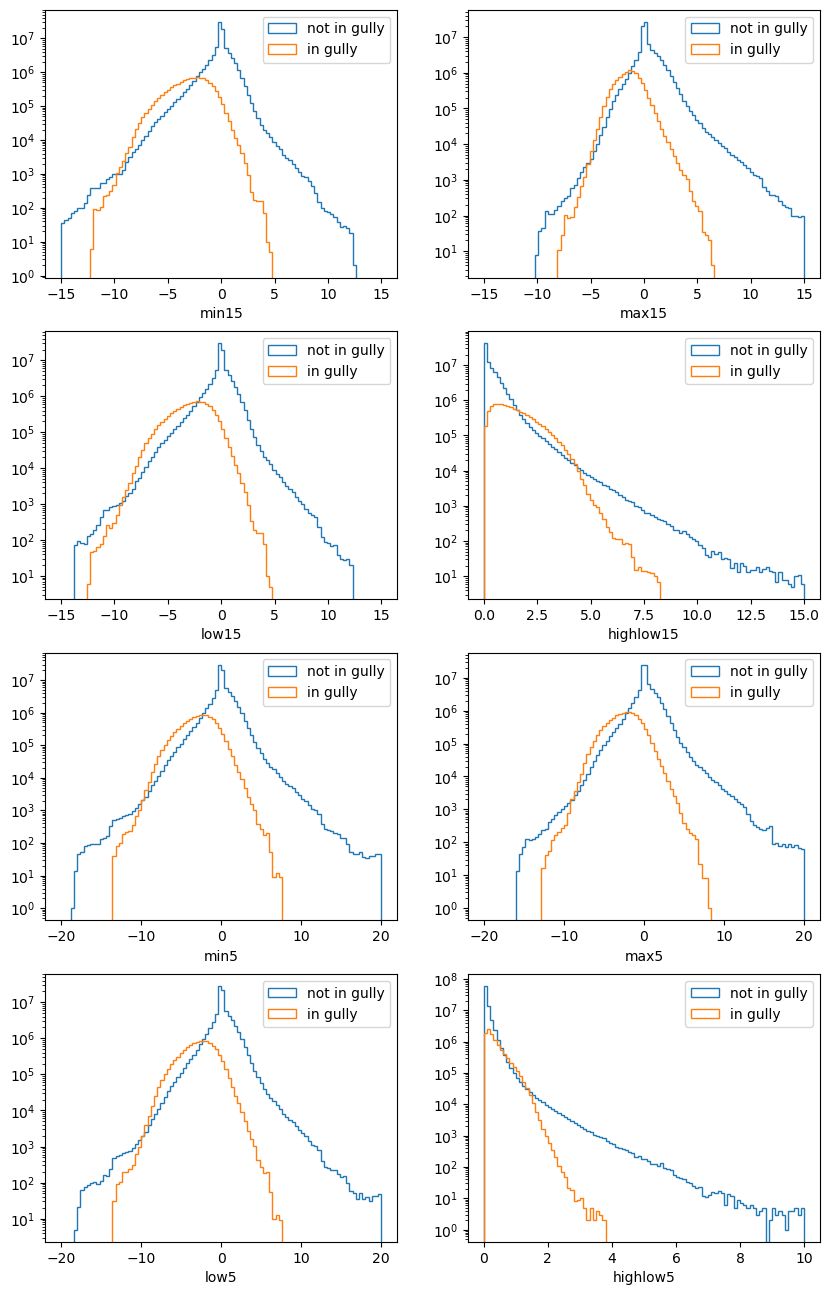

In [6]:
fig, axs = plt.subplots(4, 2, figsize=(10, 16))

ranges = {
    "min15": (-15, 15),
    "max15": (-15, 15),
    "low15": (-15, 15),
    "highlow15": (0, 15),
    "min5": (-20, 20),
    "max5": (-20, 20),
    "low5": (-20, 20),
    "highlow5": (0, 10),
}

for ax, metric in zip(axs.flatten(), metrics):
    ax.hist(allmetrics[metric][~alltruth], bins=100, range=ranges[metric], histtype="step", label="not in gully")
    ax.hist(allmetrics[metric][alltruth], bins=100, range=ranges[metric], histtype="step", label="in gully")

    ax.legend()
    
    ax.set_yscale("log")
    ax.set_xlabel(metric)

None

In [7]:
del truth
del metrics

features = [
    "min15",
    "low15 - min15",
    "high15 - low15",
    "min5 - min15",
    "high5 - low5",
    "low15 * (high15 - low15)",
]

X = np.stack([
    allmetrics["min15"],
    allmetrics["low15"] - allmetrics["min15"],
    allmetrics["highlow15"],
    allmetrics["min5"] - allmetrics["min15"],
    allmetrics["highlow5"],
    allmetrics["low15"] * allmetrics["highlow15"],
]).T
Y = alltruth

del allmetrics
del alltruth

In [8]:
fit = sm.Logit(Y, sm.add_constant(X)).fit()

Optimization terminated successfully.
         Current function value: 0.175267
         Iterations 8


In [9]:
fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:             93752708
Model:                          Logit   Df Residuals:                 93752701
Method:                           MLE   Df Model:                            6
Date:                Tue, 07 Oct 2025   Pseudo R-squ.:                  0.4850
Time:                        17:31:11   Log-Likelihood:            -1.6432e+07
converged:                       True   LL-Null:                   -3.1904e+07
Covariance Type:            nonrobust   LLR p-value:                     0.000
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.2453      0.001  -4624.737      0.000      -4.247      -4.243
x1            -1.9073      0.001  -2781.743      0.000      -1.909      -1.906
x2             0.4205      0.005     91.216      0.000       0.411       0.430
x3             0.2861      0.002    171.294      0.000       0.283       0.289
x4             1.2096      0.002    683.827      0.000       1.206       1.213
x5             0.1254      0.003     41.988      0.000       0.120       0.131
x6             0.3487      0.000   1349.981      0.000       0.348       0.349
==============================================================================
"""

In [11]:
for feature, parameter in zip(["(intercept)"] + features, fit.params):
    print(f"{feature:25s} {parameter:9.6f}")

(intercept)               -4.245255
min15                     -1.907335
low15 - min15              0.420469
high15 - low15             0.286131
min5 - min15               1.209608
high5 - low5               0.125410
low15 * (high15 - low15)   0.348683


In [12]:
cov_mat = fit.cov_params()
stdev = np.sqrt(np.diag(cov_mat))
corr_mat = cov_mat / np.outer(stdev, stdev)

pd.DataFrame(corr_mat, index=["(intercept)"] + features, columns=["(intercept)"] + features).style.background_gradient(
    cmap="coolwarm", vmin=-1, vmax=1
)

,(intercept),min15,low15 - min15,high15 - low15,min5 - min15,high5 - low5,low15 * (high15 - low15)
(intercept),1.000000,0.537683,-0.012111,-0.176677,-0.131670,-0.063990,-0.502303
min15,0.537683,1.000000,0.273175,0.463580,-0.526928,-0.305591,-0.357901
low15 - min15,-0.012111,0.273175,1.000000,0.257445,-0.178632,-0.429273,0.043470
high15 - low15,-0.176677,0.463580,0.257445,1.000000,-0.705017,-0.645639,0.506222
min5 - min15,-0.131670,-0.526928,-0.178632,-0.705017,1.000000,0.322170,-0.334116
high5 - low5,-0.063990,-0.305591,-0.429273,-0.645639,0.322170,1.000000,-0.099428
low15 * (high15 - low15),-0.502303,-0.357901,0.043470,0.506222,-0.334116,-0.099428,1.000000


In [13]:
test_samples = np.stack([np.ones(1000)] + [np.random.uniform(-10, 10, 1000) for _ in features]).T

predictions = fit.predict(test_samples)

def logistic(x):
    return 1/(1 + np.exp(-x))

for test_sample, prediction in zip(test_samples, predictions):
    assert logistic(fit.params @ test_sample.T) == prediction

In [19]:
fit.params.tolist()

[-4.245255247761359,
 -1.9073347423513844,
 0.42046946913694905,
 0.2861306499246818,
 1.2096084741278526,
 0.12541040063766767,
 0.34868286562470935]

In [34]:
for test_sample, prediction in zip(test_samples, predictions):
    assert abs(
            logistic(
            -4.245255247761359
            + -1.9073347423513844 * test_sample[1]  # min15
            + 0.42046946913694905 * test_sample[2]  # low15 - min15
            + 0.2861306499246818 * test_sample[3]   # high15 - low15
            + 1.2096084741278526 * test_sample[4]   # min5 - min15
            + 0.12541040063766767 * test_sample[5]  # high5 - low5
            + 0.34868286562470935 * test_sample[6]  # low15 * (high15 - low15)
        ) - prediction
    ) < 1e-15

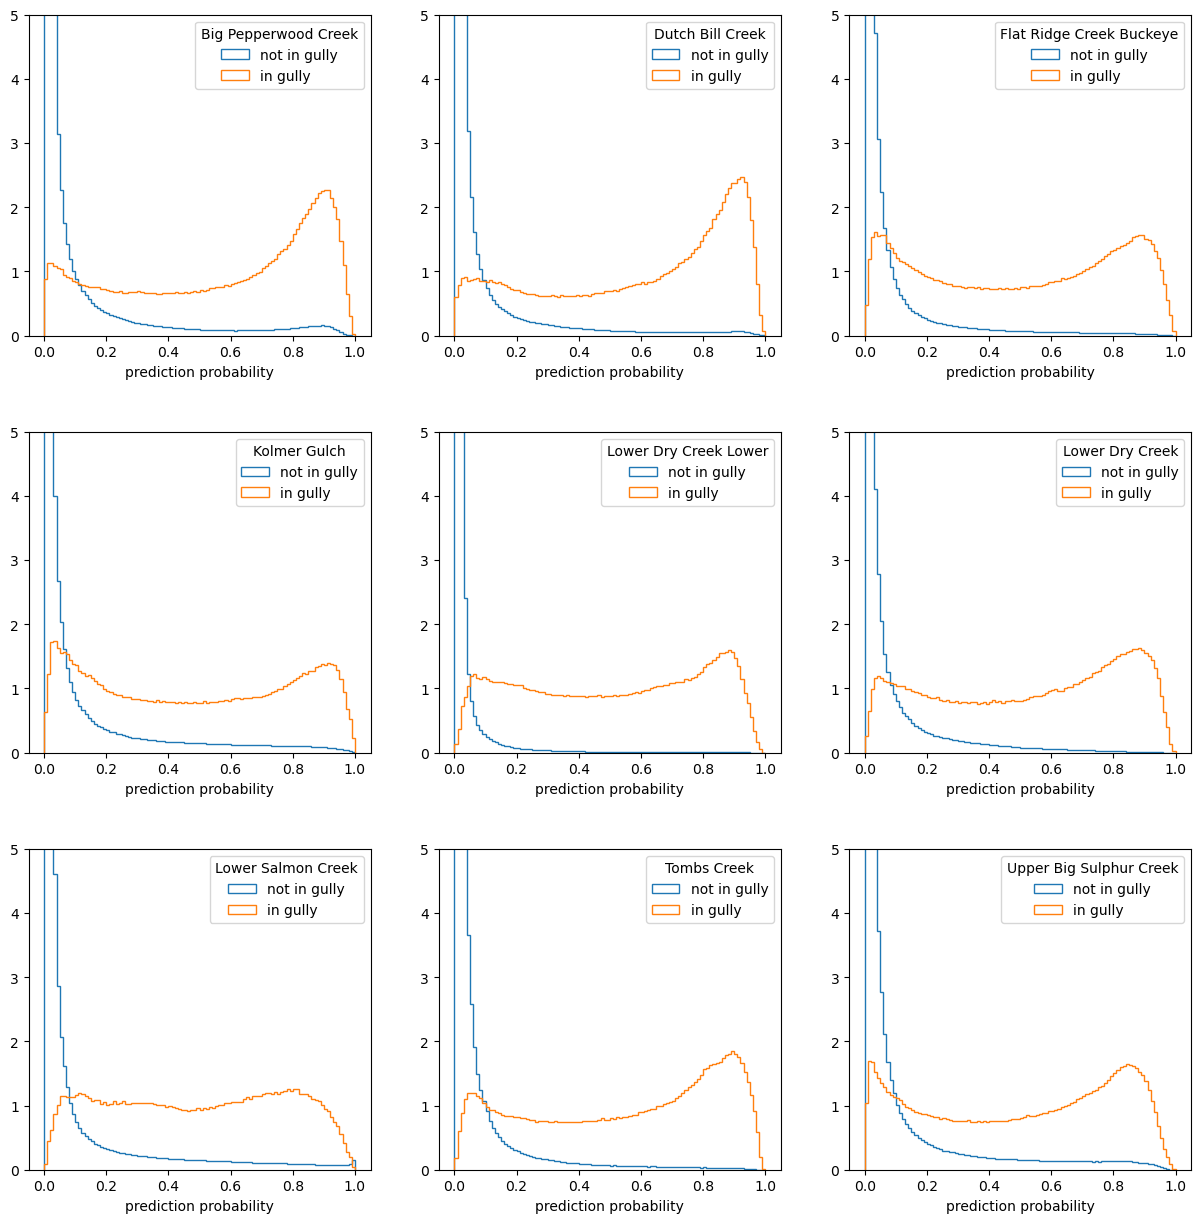

In [14]:
fig, axs = plt.subplots(3, 3, figsize=(15, 15))

for ax, name, slc in zip(axs.flatten(), names, slices):
    ax.hist(fit.predict(sm.add_constant(X)[slc][~Y[slc]]), bins=100, range=(0, 1), density=True, histtype="step", label="not in gully")
    ax.hist(fit.predict(sm.add_constant(X)[slc][Y[slc]]), bins=100, range=(0, 1), density=True, histtype="step", label="in gully")

    ax.legend(loc="upper right", title=names[name])

    ax.set_ylim(0, 5)
    ax.set_xlabel("prediction probability")

plt.subplots_adjust(hspace=0.3)

None

In [15]:
name = "dutch"

with PIL.Image.open(DIRECTORY / "hand-labeled" / f"{names[name]}-mask.png") as file:
    mask = np.asarray(file)[:, :, 1] < 128

with PIL.Image.open(DIRECTORY / "hand-labeled" / f"{names[name]}-gully.png") as file:
    gully = (np.asarray(file)[:, :, 1] > 128).astype(np.float32)

gully[~mask] = np.nan

metrics = {
    "min15": None,
    "max15": None,
    "low15": None,
    "highlow15": None,
    "min5": None,
    "max5": None,
    "low5": None,
    "highlow5": None,
}
for metric in metrics:
    with rasterio.open(DIRECTORY / "derived" / metric / f"{names[name]}-{metric}.tif") as file:
        data = file.read(1)
    np.logical_and(mask, ~np.isnan(data), out=mask)  # assumes they all have NaNs in the same places
    metrics[metric]= data

In [16]:
X_test = np.stack([
    metrics["min15"],
    metrics["low15"] - metrics["min15"],
    metrics["highlow15"],
    metrics["min5"] - metrics["min15"],
    metrics["highlow5"],
    metrics["low15"] * metrics["highlow15"],
]).transpose(1, 2, 0)

assert not np.isnan(X_test[mask]).any()
X_test[np.isnan(X_test)] = 0

In [17]:
probability = fit.predict(sm.add_constant(X_test.reshape(-1, len(features)))).reshape(mask.shape)
probability[~mask] = np.nan

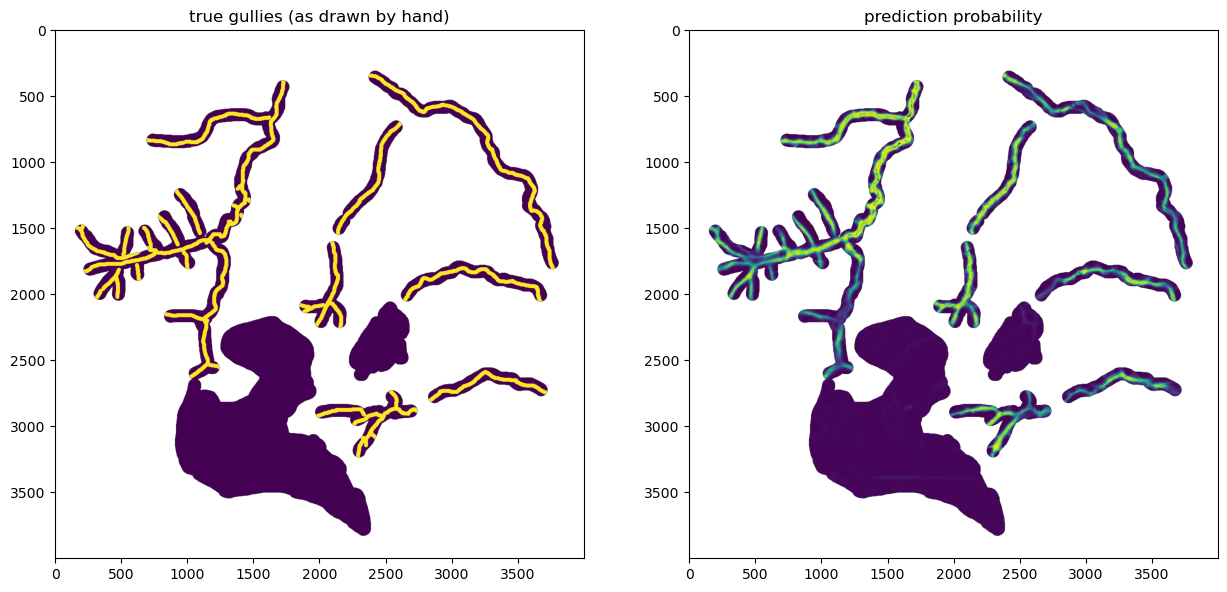

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10))

ax1.imshow(gully[15000:19000, 14000:18000])
ax2.imshow(probability[15000:19000, 14000:18000])

ax1.set_title("true gullies (as drawn by hand)")
ax2.set_title("prediction probability")

None